Naive Bayes Classifier

## Title:
Write a program to implement the Naïve Bayesian classifier for a sample training data set stored
as a .CSV file. Compute the accuracy of the classifier, considering few test data sets.

# Multinomial Naive Bayes Classifier

## Load Dataset


In [1]:
import sys

!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn kagglehub tensorflow seaborn


[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kashishparmar02/social-media-sentiments-analysis-dataset")

print("Path to dataset files:", path)

c:\Users\rutal\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 50.9k/50.9k [00:00<00:00, 561kB/s]

Extracting files...
Path to dataset files: C:\Users\rutal\.cache\kagglehub\datasets\kashishparmar02\social-media-sentiments-analysis-dataset\versions\3


In [3]:
import pandas as pd
import os

print(os.listdir(path))

['sentimentdataset.csv']


In [4]:
df = pd.read_csv(os.path.join(path, "sentimentdataset.csv"))

df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


## Preprocess Text Data

In [6]:
import re

text_column = 'Text'      # change if different
label_column = 'Sentiment'    # change if different

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    return text.strip()

df[text_column] = df[text_column].apply(clean_text)

# Remove empty rows
df = df[df[text_column] != ""]


## Encode Labels

In [7]:
from sklearn.preprocessing import LabelEncoder

print(f"\nUnique values in '{label_column}' before encoding:")
print(df[label_column].value_counts())

def map_sentiment(sentiment):
    sentiment = str(sentiment).lower()
    if 'positive' in sentiment or 'joy' in sentiment or 'excitement' in sentiment or 'happy' in sentiment or 'love' in sentiment or 'good' in sentiment or 'optimism' in sentiment or 'enthusiasm' in sentiment or 'amusement' in sentiment or 'vibrancy' in sentiment or 'thrilling' in sentiment or 'mesmerizing' in sentiment or 'delight' in sentiment or 'bliss' in sentiment or 'wonder' in sentiment:
        return 'Positive'
    elif 'negative' in sentiment or 'sad' in sentiment or 'anger' in sentiment or 'fear' in sentiment or 'disappointment' in sentiment or 'frustration' in sentiment or 'bad' in sentiment or 'stress' in sentiment or 'anxiety' in sentiment or 'terrible' in sentiment or 'exhaustion' in sentiment or 'regret' in sentiment or 'grief' in sentiment or 'melancholy' in sentiment or 'dread' in sentiment:
        return 'Negative'
    else:
        return 'Neutral'

df[label_column] = df[label_column].apply(map_sentiment)

print(f"\nUnique values in '{label_column}' after mapping:")
print(df[label_column].value_counts())

le = LabelEncoder()
df[label_column] = le.fit_transform(df[label_column])


Unique values in 'Sentiment' before encoding:
Sentiment
Positive         44
Joy              42
Excitement       32
Contentment      14
Neutral          14
                 ..
Boredom           1
Indifference      1
Disgust           1
Relief            1
Positive          1
Name: count, Length: 279, dtype: int64

Unique values in 'Sentiment' after mapping:
Sentiment
Neutral     502
Positive    170
Negative     60
Name: count, dtype: int64


## Convert Text to Numeric

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df[text_column])
y = df[label_column]

## Split Data


In [10]:
from sklearn.model_selection import train_test_split
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (585, 2300)
Shape of X_test: (147, 2300)
Shape of y_train: (585,)
Shape of y_test: (147,)


## Train Multinomial Naïve Bayes Classifier


In [11]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

print("Multinomial Naive Bayes classifier trained successfully.")

Multinomial Naive Bayes classifier trained successfully.


## Predict and Evaluate Accuracy

Model Accuracy: 0.6939

Classification Report:

              precision    recall  f1-score   support

           0       0.45      0.69      0.55        13
           1       0.84      0.68      0.75        96
           2       0.56      0.74      0.64        38

    accuracy                           0.69       147
   macro avg       0.62      0.70      0.64       147
weighted avg       0.74      0.69      0.70       147


Confusion Matrix:

[[ 9  3  1]
 [10 65 21]
 [ 1  9 28]]





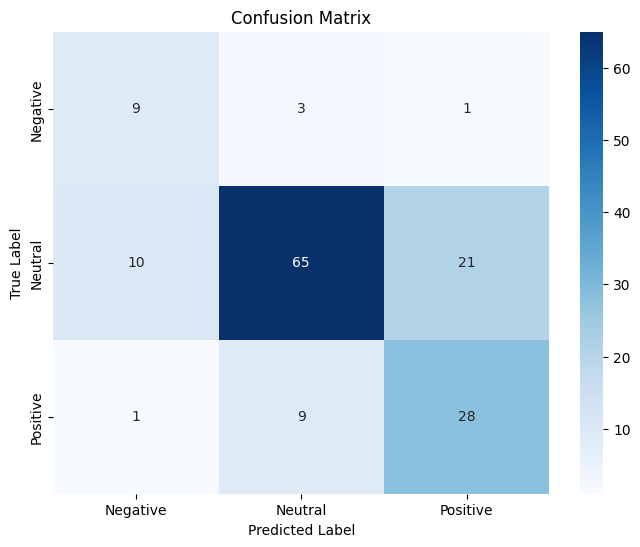

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Predict the sentiment labels on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))
print("\n\n")

import matplotlib.pyplot as plt
import seaborn as sns

# Get the class names from the LabelEncoder
class_names = le.classes_

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Gaussian Naive Bayes Classifier

## Import Libraries & Load Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dnkumars/cybersecurity-intrusion-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 261k/261k [00:00<00:00, 301kB/s]

Extracting files...
Path to dataset files: C:\Users\rutal\.cache\kagglehub\datasets\dnkumars\cybersecurity-intrusion-detection-dataset\versions\2


In [15]:
import pandas as pd
import os

print(os.listdir(path))

['cybersecurity_intrusion_data.csv']


In [16]:
df = pd.read_csv(
    os.path.join(path, "cybersecurity_intrusion_data.csv")
)

df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


## Preprocess Data

In [17]:
df = df.dropna()

# Separate Features & Target
X = df.drop(columns=['session_id', df.columns[-1]]) # Drop session_id and the target column
y = df.iloc[:, -1]

# Encode target if categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    class_names = le.classes_
else:
    class_names = np.unique(y)

# Identify categorical columns in X
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
# Apply one-hot encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

C:\Users\rutal\AppData\Local\Temp\ipykernel_33604\297040258.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns


## Feature Scaling

In [18]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

## Split Dataset

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (6056, 13)
Shape of X_test: (1515, 13)
Shape of y_train: (6056,)
Shape of y_test: (1515,)


## Train Gaussian Naive Bayes Classifier

In [20]:
model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## Predict & Evaluate


Model Accuracy: 0.834983498349835

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.94      0.86       841
           1       0.91      0.70      0.79       674

    accuracy                           0.83      1515
   macro avg       0.85      0.82      0.83      1515
weighted avg       0.85      0.83      0.83      1515



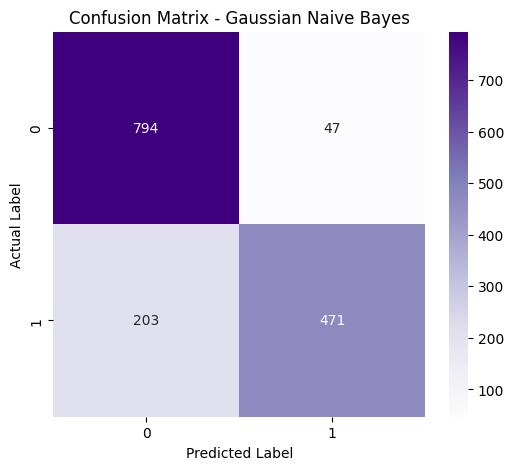

In [21]:
# Predict
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.show()